In [1]:
import scanpy as sc
import os 
import scvi
import seaborn as sns
import torch
from rich import print
import numpy as np
import scanpy.external as sce


adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/six_datasets_4v3_500_1000gene/TH_downsampled_ratio.h5ad")
adata.obs["celltype.L2"].value_counts()
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# 选择第二最多的细胞
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# z只选male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
#去掉名字包含MW22B的样本
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata.obs["celltype.L2"].value_counts()


celltype.L2
MOL-1                      23858
Astrocyte-1                21068
TH Tll1_Thsd7b Glut        19158
MOL-2                      18150
TH Tnc_Cdh20 Glut          16458
TH Car4_Tspan11 Glut       15618
TH Cald1_Gm39185 Glut      12666
TH Fam20a_Fbln1 Glut       12130
TH Kcnk13_Nox4 Glut         8049
OPC                         7460
TH Ccdc192_Gli3 Glut        7451
TH Meis2_Gm2115 GABA        6763
TH Fgf10_Gm16263 Glut       4859
TH Parm1_Mdga1 Glut         4618
MOL-3                       4239
TH Egflam_Fbn2 Glut         3528
TH Tac2_Pde11a Glut         2643
Astrocyte-3                 2281
TH Col27a1_Npsr1 Glut       2077
MFOL                        2015
Astrocyte-4                 1299
Microglia-1                 1095
COP                          909
Endothelial cell             702
Choroid plexus cell          590
Ependymal cell               589
Microglia-2                  584
VLMC                         308
NFOL                         180
Pericyte                     15

In [3]:
# === 3. 数据结构探索（SCVI setup 前置） ===
print(f"shape: {adata_subset.shape}")
print(f"X dtype : {adata_subset.X.dtype}   X range: [{adata_subset.X.min()}, {adata_subset.X.max()}]")
print(f"layers  : {[k for k in adata_subset.layers.keys() if k is not None]}")

# 关键列 value counts —— 与 RUVDEG 一致的元信息
for col in ["status", "company", "celltype.L2", "sex", "sample", "region"]:
    if col in adata_subset.obs.columns:
        vc = adata_subset.obs[col].value_counts()
        print(f"\n{col} (n_unique={vc.size}):")
        print(vc.head(10))


shape: (13885, 16428)

X dtype : float32   X range: [0.0, 1900.0]

layers  : ['counts']

status (n_unique=5):

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

...

sex
M    13885
Name: count, dtype: int64

sample (n_unique=17):

sample
MC25B_TH_yunzhun      1748
CSRS1-3_TH_beirui     1206
CS2-1_TH_beirui       1201
CSRS9-1_TH_beirui     1109
CSRS10-3_TH_beirui    1092
CS1-1_TH_beirui       1033
MW45A_TH_beirui        964
MC50E_TH_beirui        917
MC52B_TH_beirui        795
CS7-3_TH_beirui        714
Name: count, dtype: int64

region (n_unique=1):

region
TH    13885
Name: count, dtype: int64

In [4]:
adata_subset.obs.status.value_counts()

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

In [5]:
adata_subset.layers["counts"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 21352213 stored elements and shape (13885, 16428)>

In [6]:
# === 5. n_genes_on 协变量（mirror RUVDEG cell 4） ===
# 用 raw counts 计算每个细胞 >0 的基因数，标准化后作为连续 nuisance covariate。
# 与 RUVDEG 完全一致：mean/std 由本次数据估计，z-score 后写入 adata.obs["n_genes_on"]。
n_genes_on_raw = (adata_subset.layers["counts"] > 0).sum(axis=1).astype(np.float32)
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std  = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")

adata_subset.obs["n_genes_on"] = (
    (n_genes_on_raw - n_genes_on_mean) / n_genes_on_std
).astype(np.float32)

print(f"raw mean / std    : {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: [{adata_subset.obs['n_genes_on'].min():.3f}, "
      f"{adata_subset.obs['n_genes_on'].max():.3f}]")


/tmp/ipykernel_381423/1198264137.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["n_genes_on"] = (


raw mean / std    : 1537.8 / 451.2

standardized range: [-1.996, 5.570]

In [7]:
adata_subset.X = adata_subset.layers["counts"].copy()

In [8]:
# === 6. SCVI setup_anndata（mirror RUVDEG covariate 设计） ===
#
# RUVDEG → SCVI 映射：
#   batch (技术)         -> batch_key="company"
#   n_genes_on (连续)    -> continuous_covariate_keys=["n_genes_on"]
#   group (生物学 status) -> NOT 注册：SCVI 无监督，biology 体现在 latent z；
#                              保留在 adata.obs["status"] 供下游 DEG 使用。
# 不传 labels_key：本数据只含单个 L2 细胞类型，且 labels_key 语义上是细胞类型标签、
# 不是 biology-of-interest，作 covariate-as-label 会语义错误。

BATCH_KEY = "company"
CONT_COVS = ["n_genes_on"]

scvi.model.SCVI.setup_anndata(
    adata_subset,
    layer=None,                              # raw counts 在 adata.X
    batch_key=None,                     # technical nuisance (RUVDEG `batch`)
    labels_key=None,                         # no cell-type label here
    categorical_covariate_keys=None,         # no extra categorical nuisance
    continuous_covariate_keys=None,     # technical continuous nuisance (RUVDEG `n_genes_on`)
)
print(f"✓ scvi.model.SCVI.setup_anndata complete")
print(f"  manager uuid: {adata_subset.uns['_scvi_manager_uuid'][:8]}…")


✓ scvi.model.SCVI.setup_anndata complete

manager uuid: 3cb95454…

In [9]:
# === 6b. 自动选择最空闲的 GPU ===

if torch.cuda.is_available():

    gpu_memory = []

    for gpu_idx in range(torch.cuda.device_count()):

        with torch.cuda.device(gpu_idx):

            free_bytes, total_bytes = torch.cuda.mem_get_info()

        gpu_memory.append((gpu_idx, free_bytes, total_bytes))



    BEST_GPU, BEST_GPU_FREE, BEST_GPU_TOTAL = max(gpu_memory, key=lambda x: x[1])

    TRAIN_ACCELERATOR = "gpu"

    TRAIN_DEVICES = [BEST_GPU]

    print(

        f"✓ select gpu:{BEST_GPU}  free={BEST_GPU_FREE / 1024**3:.2f} GiB / "

        f"total={BEST_GPU_TOTAL / 1024**3:.2f} GiB"

    )

else:

    BEST_GPU = None

    TRAIN_ACCELERATOR = "cpu"

    TRAIN_DEVICES = 1

    print("CUDA not available, fallback to CPU")


✓ select gpu:4  free=77.08 GiB / total=79.15 GiB

In [10]:
model = scvi.model.SCVI(adata_subset, n_layers=2, n_latent=32, gene_likelihood="zinb")

model.train(accelerator=TRAIN_ACCELERATOR, devices=TRAIN_DEVICES)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/junyichen/anaconda3/envs/scvi-env/lib

Epoch 400/400: 100%|██████████| 400/400 [05:00<00:00,  1.55it/s, v_num=1, train_loss=4.63e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:00<00:00,  1.33it/s, v_num=1, train_loss=4.63e+3]


In [11]:
SCVI_LATENT_KEY = "X_scVI"
adata_subset.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [14]:
adata_subset.obsm['X_pcaBACK'] = adata_subset.obsm['X_pca'].copy()


In [17]:
adata_subset.obsm['X_pca'] = adata_subset.obsm[SCVI_LATENT_KEY].copy()

In [27]:
adata_subset.obsm['X_pca'].shape

(13885, 32)

In [32]:
adata_subset.obs.columns

Index(['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score',
       'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score',
       'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor',
       'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads',
       'median_umi', 'median_genes', 'total_genes', 'mapped_genome',
       'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic',
       'mapped_exonic', 'mapped_transcriptome', 'antisense_gene',
       'reads_number', 'valid_barcodes', 'sequencing_saturation',
       'q30_barcode', 

In [30]:
from harmonypy import run_harmony
import pandas as pd

In [36]:
ho = run_harmony(adata_subset.obsm['X_pca'],
                 meta_data=pd.DataFrame(adata_subset.obs['company']),
                 vars_use='company',
                 random_state=0,
                 nclust=3,
                 max_iter_harmony=20)
# sce.pp.harmony_integrate(adata_concat, 'batch',
#                          **{'nclust':args.nclust,'lamb':args.lamb,'epsilon_harmony':0,'epsilon_cluster':0,'max_iter_harmony':10})
## lamb 11-12,lamb:0.3 is good
adata_subset.obsm['X_harmony'] = ho.Z_corr
# adata_concat.obs['umap_0'] = adata_concat.obsm['X_umap'][:, 0]
# adata_concat.obs['umap_1'] = adata_concat.obsm['X_umap'][:, 1]
# 



2026-07-31 23:07:38,650 - harmonypy - INFO - Running Harmony
2026-07-31 23:07:38,650 - harmonypy - INFO -   Parameters:
2026-07-31 23:07:38,650 - harmonypy - INFO -     max_iter_harmony: 20
2026-07-31 23:07:38,650 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-31 23:07:38,651 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-31 23:07:38,651 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-31 23:07:38,651 - harmonypy - INFO -     nclust: 3
2026-07-31 23:07:38,651 - harmonypy - INFO -     block_size: 0.05
2026-07-31 23:07:38,651 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-31 23:07:38,651 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-07-31 23:07:38,652 - harmonypy - INFO -     sigma: [0.1 0.1 0.1]
2026-07-31 23:07:38,652 - harmonypy - INFO -     verbose: True
2026-07-31 23:07:38,652 - harmonypy - INFO -     random_state: 0
2026-07-31 23:07:38,652 - harmonypy - INFO -   Data: 32 PCs × 13885 cells
2026-07-31 23:07:38,652 - harmonypy - INFO -   Batch variabl

In [38]:
sc.pp.neighbors(adata_subset, use_rep='X_harmony')


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [39]:
sc.tl.leiden(adata_subset,key_added='X_harmony')

/tmp/ipykernel_381423/2502816097.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_subset,key_added='X_harmony')


In [52]:
adata_subset.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,umap_seurat_1,umap_seurat_2,Neurotransmitter,doublet_cluster,celltype,Model,n_genes_on,_scvi_batch,_scvi_labels,X_harmony
AAAGGGCAGAGAGGGC-1TH_beirui_MW51A,MW51A_TH_beirui,951,6.858565,1602.0,7.379632,33.270911,41.136080,53.121099,71.847690,0.0,...,5.027751,1.668857,NN,0,Astrocyte-1,CON_M,-1.309276,0,0,2
AACACACTCGTGCATA-1TH_beirui_MW51A,MW51A_TH_beirui,1112,7.014814,1809.0,7.501082,29.906025,37.479270,48.535102,66.169154,5.0,...,1.200006,3.774553,NN,0,Astrocyte-1,CON_M,-0.950261,0,0,2
AACCATGTCAATCGGT-1TH_beirui_MW51A,MW51A_TH_beirui,929,6.835185,1525.0,7.330405,33.377049,40.590164,52.196721,71.868852,2.0,...,2.964679,-0.261776,NN,0,Astrocyte-1,CON_M,-1.358031,0,0,2
AACCCAAAGCTCCGAC-1TH_beirui_MW51A,MW51A_TH_beirui,984,6.892642,1677.0,7.425358,33.035182,40.966011,52.892069,71.138939,0.0,...,2.930069,3.113483,NN,0,Astrocyte-1,CON_M,-1.231711,0,0,2
AACTTCTTCGAGCTGC-1TH_beirui_MW51A,MW51A_TH_beirui,992,6.900731,1824.0,7.509336,37.719298,44.901316,55.866228,73.026316,0.0,...,4.748067,1.262970,NN,1,Astrocyte-1,CON_M,-1.222847,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCGCTTAA-1TH_beirui_CSRS9-1,CSRS9-1_TH_beirui,1902,7.551187,3922.0,8.274612,33.350331,39.979602,48.342682,64.201938,3.0,...,6.149463,2.650445,NN,0,Astrocyte-1,CSRES_M,0.749523,0,0,8
TTTGGTTTCGCCTCTA-1TH_beirui_CSRS9-1,CSRS9-1_TH_beirui,1548,7.345365,2709.0,7.904704,31.524548,37.320044,45.478036,61.314138,3.0,...,0.528194,1.797504,NN,0,Astrocyte-1,CSRES_M,-0.015047,0,0,4
TTTGTTGAGCACTCAT-1TH_beirui_CSRS9-1,CSRS9-1_TH_beirui,1396,7.242082,2365.0,7.768956,27.949260,34.714588,44.186047,62.114165,3.0,...,3.840803,2.951406,NN,0,Astrocyte-1,CSRES_M,-0.349685,0,0,5
TTTGTTGAGCACTCTA-1TH_beirui_CSRS9-1,CSRS9-1_TH_beirui,1196,7.087574,2217.0,7.704361,38.836265,44.384303,53.405503,68.606225,2.0,...,2.836313,0.011403,NN,0,Astrocyte-1,CSRES_M,-0.786266,0,0,4


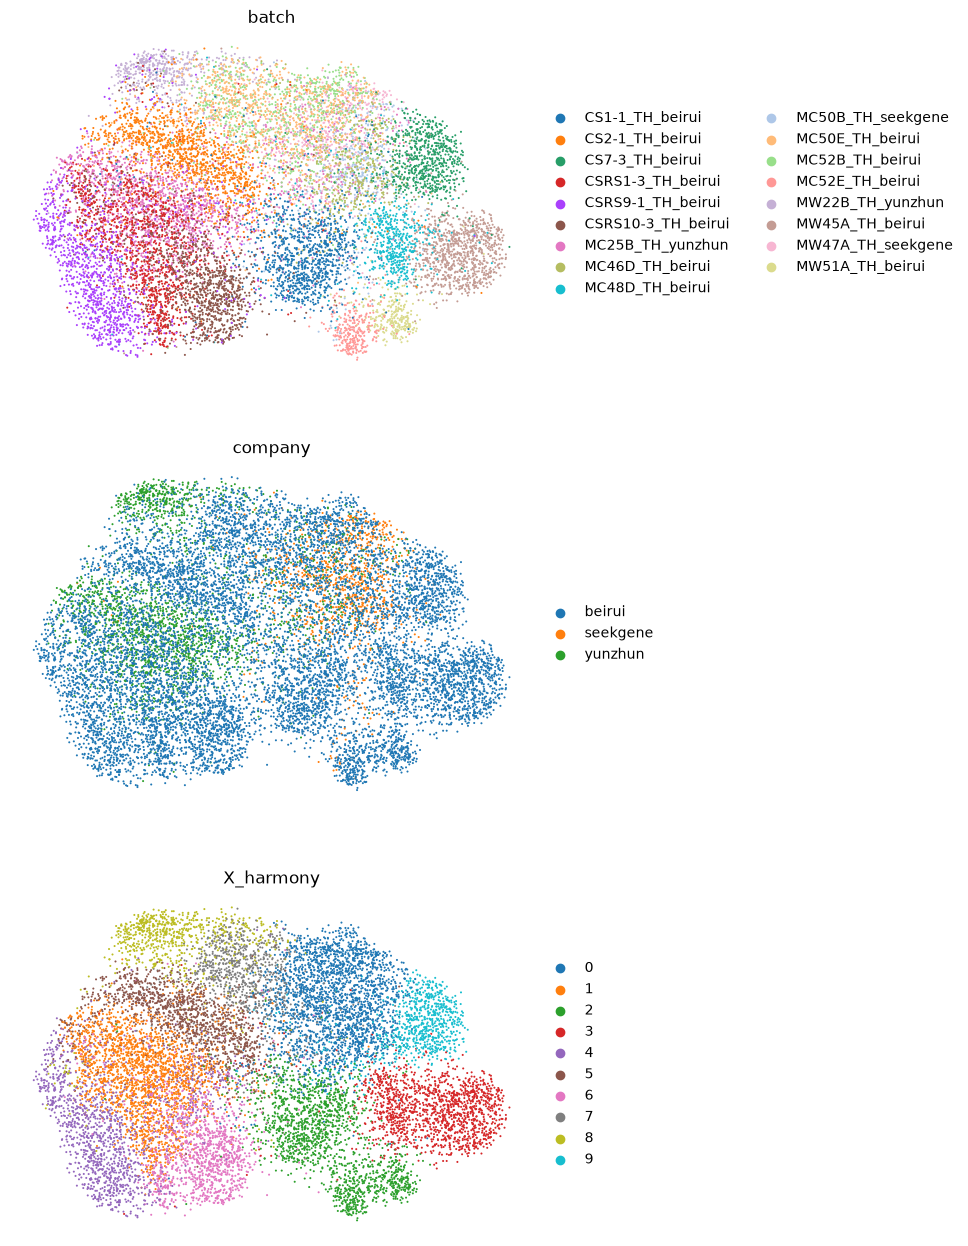

In [53]:
sc.tl.umap(adata_subset, min_dist=0.3,neighbors_key="neighbors")
sc.pl.umap(
    adata_subset,
    color=["batch","company", "X_harmony"],
    frameon=False,
    ncols=1,
)

In [ ]:
# batch_idx = model.adata_manager.get_from_registry("batch")
# cont_cov = model.adata_manager.get_from_registry("extra_continuous_covs")
# cont_cov = torch.as_tensor(
#     pd.DataFrame(cont_cov).to_numpy(dtype=np.float32),
#     device=next(model.module.parameters()).device,
# )

# adata_subset.obs['batch_idx'] = batch_idx

# batch_map = dict(zip(adata_subset.obs['company'].values, adata_subset.obs['batch_idx'].values))
# batch_map

In [ ]:
X_norm = model.get_normalized_expression(
    lib_size=1e4, transform_batch="beirui"
)
adata_subset.layers["scvi_nrom_counts"] = X_norm

In [ ]:
# === 用指定的 z 直接 decode（绕过 encoder，不做 q(z|x) 采样） ===
# scvi 的 posterior_predictive_sample / get_normalized_expression 都不接受自定义 z，
# 它们内部会走 encoder 重新采样。要"指定 z 去 decode"，直接调 module.generative()。
#
# 本 notebook 的模型 setup 为 batch_key=None + continuous_covariate_keys=None，
# 因此 batch_index 全 0、cont_covs=None。若模型注册了 batch / covs，需相应传值。
import torch
import numpy as np


def decode_from_z(model, adata, z, library_size=None, batch_size=512):
    """用自定义 latent z 直接跑 decoder（generative），返回 ZINB 分布。

    Parameters
    ----------
    model : scvi.model.SCVI（训练后）
    adata : AnnData（与模型 setup 结构一致）
    z : (n_cells, n_latent) 数组 —— 自定义 latent，例如：
        - adata_subset.obsm['X_harmony']（harmony 校正后的 z）
        - adata_subset.obsm['X_scVI']（latent mean，即 q(z|x) 的均值，无采样噪声）
    library_size : (n_cells,) 或 None
        None 时用观测 library size = log(rowSums(counts))，即固定测序深度。
        想模拟"真实后验"的 library 可改用 model.get_latent_representation() 同源估计，
        或用 encoder 的 ql 均值（见下方注释掉的替代方案）。

    Returns
    -------
    px : scvi.distributions 分布对象
        px.sample() 得到 (n_cells, n_genes) counts 抽样
        px.mean    得到 (n_cells, n_genes) 期望表达（rate）
    """
    module = model.module
    z = torch.as_tensor(np.asarray(z, dtype=np.float32))

    # batch_index：模型 batch_key=None -> 全 0；若注册了 batch 需用真实 code
    batch_index = torch.zeros((adata.n_obs, 1), dtype=torch.long)

    # library：观测 library size（log 尺度），decoder 内部 exp(library)*px_scale
    if library_size is None:
        counts = adata.layers["counts"] if "counts" in adata.layers else adata.X
        lib = np.asarray(counts.sum(axis=1)).ravel()
        library = torch.log(torch.tensor(lib, dtype=torch.float32)).unsqueeze(1)
    else:
        library = torch.log(
            torch.tensor(np.asarray(library_size, dtype=np.float32))
        ).unsqueeze(1)

    # 若模型注册了连续协变量（continuous_covariate_keys），需从 obs 取出对应列传 cont_covs
    cont_covs = None  # 本 notebook: continuous_covariate_keys=None

    with torch.inference_mode():
        gen_out = module.generative(
            z=z,
            library=library,
            batch_index=batch_index,
            cont_covs=cont_covs,
        )
    return gen_out["px"]  # px: ZINB 分布


def normalized_expression_from_z(model, adata, z, lib_size=1):
    """用自定义 latent z 直接算归一化表达（等价于"指定 z 的 get_normalized_expression"）。

    语义与 scvi 官方 get_normalized_expression 完全一致：
    返回 px_scale * lib_size，即每个基因在解码分布中的相对表达（softmax 权重）
    乘以 library_size 尺度。默认 lib_size=1 -> 每细胞行和为 1（相对比例）。

    与官方版本的差别仅在于：不经过 encoder 采样 z，而是用传入的自定义 z。

    Parameters
    ----------
    model : scvi.model.SCVI（训练后）
    adata : AnnData（与模型 setup 结构一致）
    z : (n_cells, n_latent) 数组 —— 自定义 latent
    lib_size : float 或 (n_cells,)
        同官方 library_size 参数：乘以 px_scale 的尺度因子。
        默认 1（返回每细胞行和=1 的相对表达比例）；
        传 1e4 则得到每 1 万 counts 的标准化表达。

    Returns
    -------
    np.ndarray of shape (n_cells, n_genes) —— 归一化表达（rate 的比例）
    """
    px = decode_from_z(model, adata, z)
    scale = px.scale  # (n_cells, n_genes) softmax 权重
    if np.isscalar(lib_size) or (isinstance(lib_size, (int, float))):
        scale = scale * lib_size
    else:
        scale = scale * torch.tensor(np.asarray(lib_size, dtype=np.float32)).unsqueeze(1)
    return scale.numpy()

In [ ]:
# === 演示：用指定 z 直接 decode / 归一化表达 ===

# 1) 用 harmony 校正后的 z（或 X_scVI latent mean）
z_custom = adata_subset.obsm["X_harmony"]  # (n_cells, n_latent)

# 2) decode：返回 ZINB 分布
px = decode_from_z(model, adata_subset, z_custom)

# 3) 从分布抽样 counts（等价于"指定 z 的 posterior predictive sample"）
recon_custom = px.sample().cpu().numpy()
print(f"reconstructed shape: {recon_custom.shape}")
print(f"range: [{recon_custom.min()}, {recon_custom.max()}]  median={np.median(recon_custom):.2f}")
print(f"fraction non-zero: {(recon_custom > 0).mean():.3f}")

# 4) 写回 adata（注意不要覆盖默认的 scvi_reconstructed_counts）
adata_subset.layers["scvi_reconstructed_counts_harmony"] = recon_custom

# 5) 若只要期望表达（rate，不带抽样噪声）：
# px_mean = px.mean.numpy()
# adata_subset.layers["scvi_rate_harmony"] = px_mean

# 6) 等价于 get_normalized_expression 的自定义 z 版本：
#    lib_size=1   -> 相对表达（每细胞行和=1）
#    lib_size=1e4 -> 每 1 万 counts 的标准化表达（同官方常用调用）
X_norm_harmony = normalized_expression_from_z(
    model, adata_subset, z_custom, lib_size=1e4
)
print(f"normalized shape: {X_norm_harmony.shape}")
print(f"row sum (lib_size=1e4): {X_norm_harmony.sum(axis=1).mean():.0f}")

adata_subset.layers["scvi_nrom_counts_harmony"] = X_norm_harmony

reconstructed shape: (13885, 16428)

range: [0.0, 4024.0]  median=0.00

fraction non-zero: 0.093

In [47]:
recon_custom

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(13885, 16428), dtype=float32)

In [48]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes + hkg_priority

HKG available: 22 / 23

shared color: vmin=1.00, vmax=1.00

✓ saved: slide_figs/scvi_hkg_recon_status.png

✓ saved: slide_figs/raw_status.png

/tmp/ipykernel_381423/2440962853.py:68: ImplicitModificationWarning: Layer 'count_diff' should not be a np.matrix, use np.ndarray instead.
  adata_subset.layers["count_diff"] = adata_subset.layers["scvi_reconstructed_counts_harmony"] - adata_subset.layers["counts"]


✓ saved: slide_figs/count_diff.png

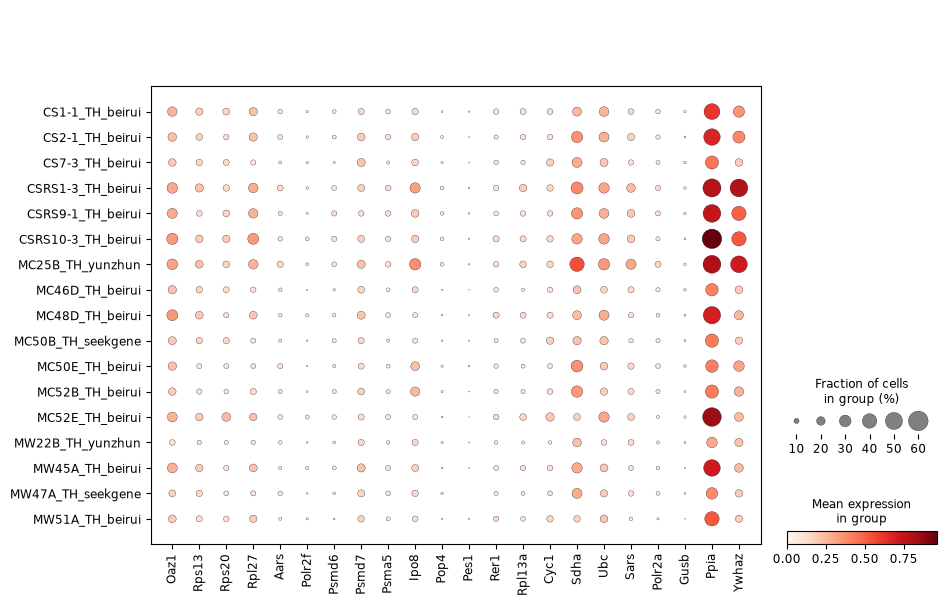

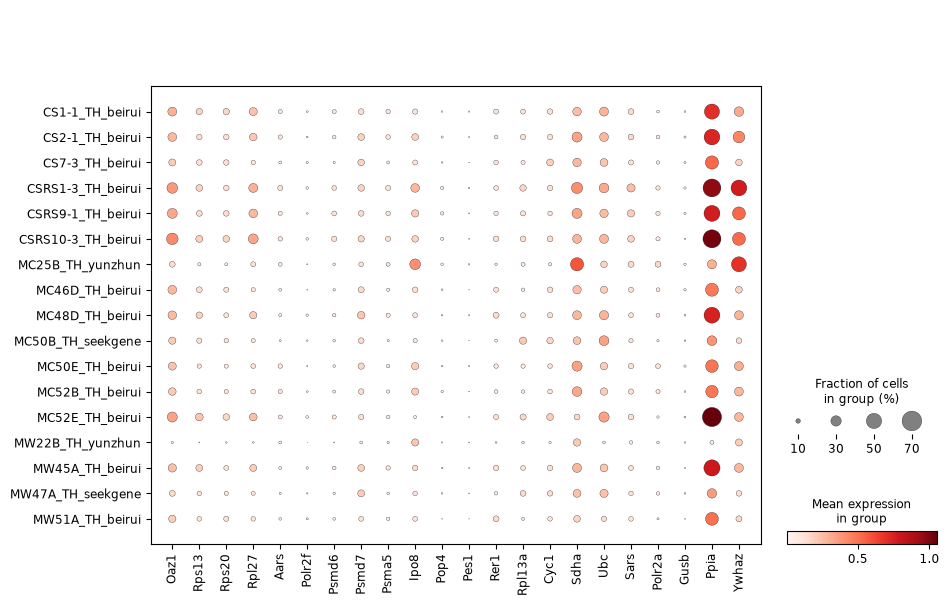

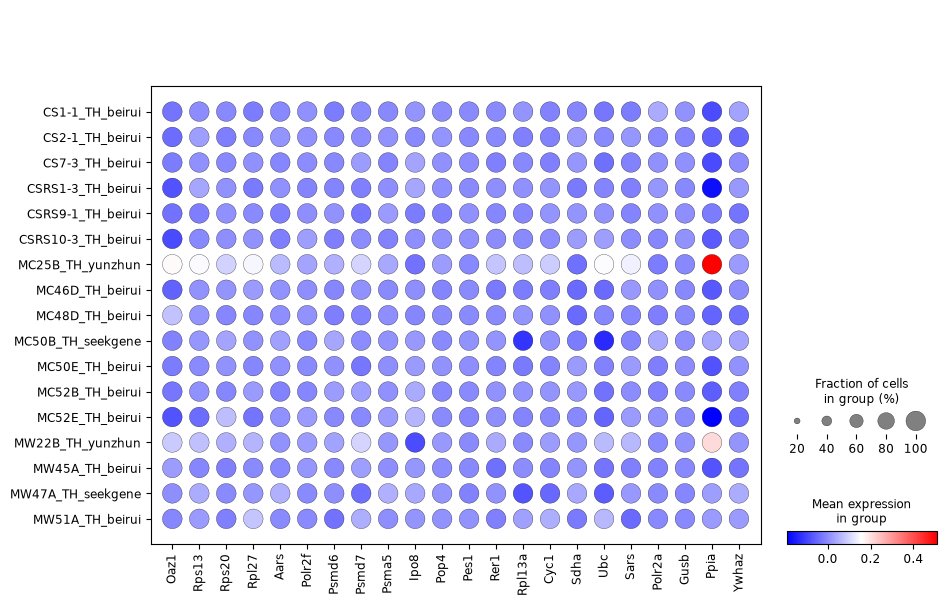

In [51]:
# ========== 9d. HKG dotplot: scvi_reconstructed_counts × status ==========
import scanpy as sc
import numpy as np

# 1) 准备 HKG 列表（保持 hkg_priority 顺序、去重、保留本数据中存在的）
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata_subset.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)
print(f"HKG available: {len(hkg_genes)} / {len(set(hkg_priority))}")

# 2) status 排序为 5 类固定顺序
adata_subset.obs["status"] = adata_subset.obs["status"].astype("category")
adata_subset.obs["status"] =adata_subset.obs["status"].cat.reorder_categories(
    ["CON", "CURES", "CUSUS", "CSRES", "CSSUS"]
)

# 3) 共享颜色尺度：把 reconstructed_counts 一起看，避免每 panel 自适应
recon = adata_subset.layers["scvi_reconstructed_counts_harmony"]
recon_arr = recon.toarray() if hasattr(recon, "toarray") else np.asarray(recon)
vmin = float(np.percentile(recon_arr[recon_arr > 0], 5))
vmax = float(np.percentile(recon_arr, 95))
print(f"shared color: vmin={vmin:.2f}, vmax={vmax:.2f}")

# 4) 画 dotplot — color = mean expr, size = % cells expressing
sc.settings.figdir = "/home/junyichen/code/RUVAEDEG/slide_figs"
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_reconstructed_counts_harmony",
    cmap="Reds",
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="scvi_hkg_recon_harmony_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/scvi_hkg_recon_harmony_status.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/scvi_hkg_recon_status.png")

sc.settings.figdir = "/home/junyichen/code/RUVAEDEG/slide_figs"
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="counts",
    cmap="Reds",
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="raw_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/raw_status.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/raw_status.png")

adata_subset.layers["count_diff"] = adata_subset.layers["scvi_reconstructed_counts_harmony"] - adata_subset.layers["counts"]
fig = sc.pl.dotplot(
    adata_subset,
    var_names=hkg_genes,
    groupby="sample",
    layer="count_diff",
    cmap="bwr",
    expression_cutoff=-1000,
    standard_scale=None,     # 用真实 counts 量级，跨组可比
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
    show=False,
    save="raw_status.png",
)
fig.savefig(
    "/home/junyichen/code/RUVAEDEG/slide_figs/count_diff.png",
    bbox_inches="tight", dpi=200,
)
print("✓ saved: slide_figs/count_diff.png")

